# Project: VisionWear AI
### Datum: 2026-06-06
### Teamleden: Michal Kakol (24087068), Sem Ooms (23091789), Chaimae Bouziani(21037078)

# 1. Setup:

In [1]:
# ==========================================
# SETUP
# ==========================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset


# ------------------------------------------
# Paths
# ------------------------------------------
# Zoek robuust naar de map "data/Dataset", ongeacht de werkmap van de kernel
# (notebooks/ of de projectroot). We lopen vanaf de huidige map omhoog en
# controleren ook de directe submappen.

def _find_dataset_dir(start: Path) -> Path:
    candidates = [start, *start.parents]
    for base in candidates:
        target = base / "data" / "Dataset"
        if (target / "Train" / "images").exists():
            return target.resolve()
    # Fallback: relatief pad zoals oorspronkelijk bedoeld
    return (start / ".." / "data" / "Dataset").resolve()


NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = _find_dataset_dir(NOTEBOOK_DIR)
PROJECT_ROOT = DATASET_DIR.parent.parent

TRAIN_IMAGES = DATASET_DIR / "Train" / "images"
TRAIN_LABELS = DATASET_DIR / "Train" / "labels"

TEST_IMAGES = DATASET_DIR / "Test" / "images"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_DIR  :", DATASET_DIR)

print(TRAIN_IMAGES)
print(TRAIN_IMAGES.exists())

print(TRAIN_LABELS)
print(TRAIN_LABELS.exists())

print(TEST_IMAGES)
print(TEST_IMAGES.exists())


# ------------------------------------------
# Class mapping
# ------------------------------------------

CLASS_NAMES = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe"
}


# ------------------------------------------
# Basic checks
# ------------------------------------------

train_images = sorted(TRAIN_IMAGES.glob("*"))
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))
test_images = sorted(TEST_IMAGES.glob("*"))

print(f"Train images : {len(train_images)}")
print(f"Train labels : {len(train_labels)}")
print(f"Test images  : {len(test_images)}")

assert len(train_images) == len(train_labels), \
    "Mismatch between train images and labels."


# ------------------------------------------
# Hugging Face dataset
# ------------------------------------------
# Uncomment once you have access

hm_dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

print(hm_dataset)


PROJECT_ROOT : C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI
DATASET_DIR  : C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Train\images
True
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Train\labels
True
C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\Dataset\Test\images
True
Train images : 2145
Train labels : 2145
Test images  : 537
DatasetDict({
    train: Dataset({
        features: ['text', 'image'],
        num_rows: 12437
    })
})


# 2. EDA:


Datadistributie en Annotaties (Objectdetectie)

De dataset voor objectdetectie bestaat uit 2.145 trainingsafbeeldingen, 2.145 bijbehorende labelbestanden en 537 testafbeeldingen. In de trainingsset zijn in totaal 8.298 geannoteerde mode-objecten aanwezig. Gemiddeld bevat elke afbeelding 3,87 objecten, waarbij het merendeel van de afbeeldingen tussen de 3 en 5 items bevat. Het maximale aantal geannoteerde objecten binnen één enkele afbeelding is 7.

Visuele inspectie van willekeurig geselecteerde afbeeldingen bevestigt dat de YOLO-annotaties correct zijn uitgelijnd met de mode-items. De bounding boxes omsluiten de kledingstukken en accessoires nauwkeurig, wat aantoont dat het labelformaat correct is geïmporteerd en dat er geen directe annotatiefouten aanwezig zijn.
Klasse-onbalans

De dataset is opgebouwd uit tien klasses: sunglass, hat, jacket, shirt, pants, shorts, skirt, dress, bag en shoe. De verdeling tussen deze categorieën is niet gelijkmatig:
- Veelvoorkomende klasses: Shoe is de meest frequente klasse (circa 25% van alle annotaties), gevolgd door shirt (17,8%) en bag (14,3%).
- Minder voorkomende klasses: Hat (3,3%) en sunglass (4,1%) zijn het minst vertegenwoordigd.

Ondanks deze onbalans bevat elke klasse minimaal enkele honderden voorbeelden, wat voldoende trainingsdata per categorie oplevert.
Dimensies en Bounding Boxes

De analyse van de bounding box-dimensies toont aan dat het merendeel van de objecten een klein tot gemiddeld deel van de afbeelding beslaat. De gemiddelde genormaliseerde breedte bedraagt 0,253 en de gemiddelde hoogte is 0,212. De gemiddelde oppervlakte van een bounding box is 0,063, met een mediaan van 0,045. Hieruit volgt dat de meeste objecten minder dan 10% van het totale afbeeldingsoppervlak beslaan. Zeer grote objecten zijn zeldzaam; de grootste bounding box beslaat circa 46% van de afbeelding. De distributie bevestigt dat de dataset hoofdzakelijk gelokaliseerde mode-items bevat in plaats van objecten die de gehele afbeelding vullen.

Alle afbeeldingen hebben een identieke resolutie van 400×600 pixels. Er is geen variatie in de afmetingen waargenomen. Deze consistentie in aspect ratio en afbeeldingsgrootte vereenvoudigt de preprocessing en elimineert de noodzaak om tijdens de training rekening te houden met wisselende resoluties.
H&M Fashion Caption Dataset en Semantische Overlap

De text-captioning dataset bevat 12.437 afbeelding-bijschriftparen. Om de relatie met de objectdetectiedataset te bepalen, is de frequentie van de tien detectieklasses binnen de bijschriften geanalyseerd:
- Hoge overlap: De modetermen dress, shirt en skirt komen het meest frequent voor. Jacket, hat en shorts zijn eveneens regelmatig aanwezig.
- Lage overlap: De term bag komt weinig voor, terwijl pants, shoe en sunglass nagenoeg afwezig zijn wanneer exact op de klassenaam wordt gezocht.

Dit duidt op een sterke conceptuele overlap voor kledingstukken van het bovenlichaam en jurken. Bepaalde detectieklasses (zoals accessoires of schoenen) komen in de omschrijvingen vermoedelijk voor onder alternatieve bewoordingen of synoniemen in plaats van de exacte klassenamen. Directe trefwoordfrequentie dient daarom te worden geïnterpreteerd als een indicatie van overlap, en niet als een volledige weergave van de semantische dekking.
Conclusie EDA

De datasets sluiten aan op de projectdoelstellingen voor het detecteren van mode-items en het genereren van tekstuele omschrijvingen. De detectiedataset levert gestructureerde annotaties op objectniveau voor tien categorieën, terwijl de H&M-dataset natuurlijke taalbeschrijvingen biedt. Samen vormen ze de basis voor een pipeline waarin objectdetectie, image captioning en het genereren van mode-afbeeldingen worden gecombineerd.

Images: 2145
Labels: 2145
Objects: 8298
Objects per image:
count    2145.000000
mean        3.868531
std         0.977576
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
dtype: float64


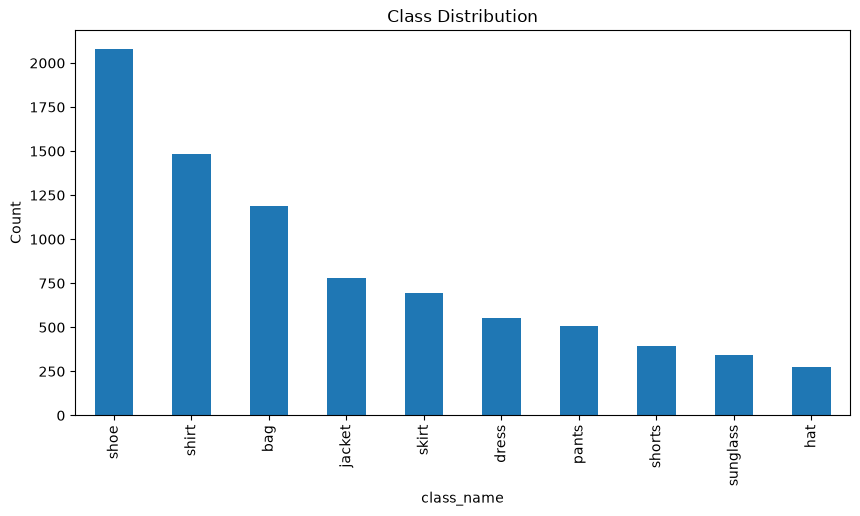

            count  percentage
class_name                   
shoe         2081       25.08
shirt        1486       17.91
bag          1188       14.32
jacket        777        9.36
skirt         697        8.40
dress         550        6.63
pants         508        6.12
shorts        395        4.76
sunglass      343        4.13
hat           273        3.29


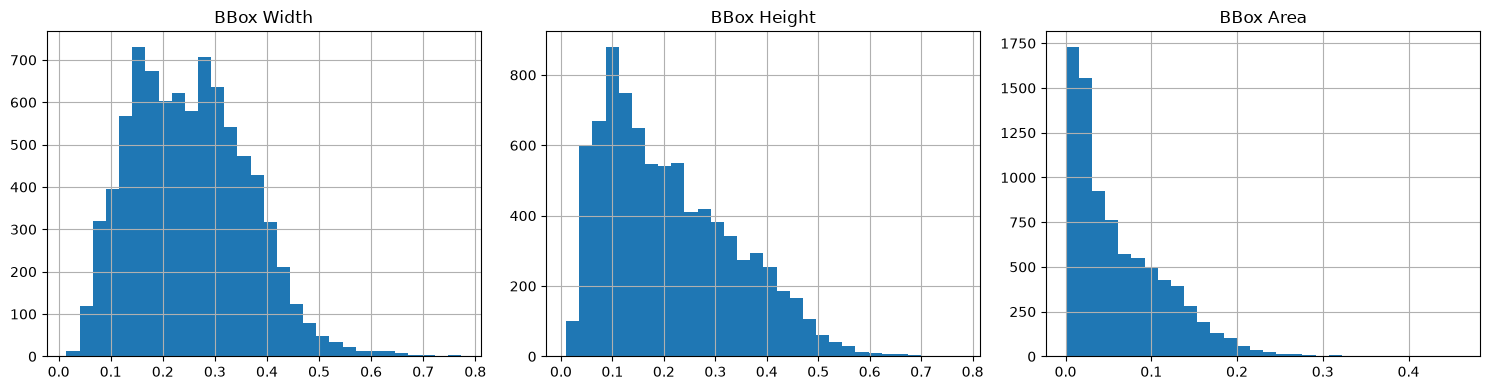

             width       height         area
count  8298.000000  8298.000000  8298.000000
mean      0.252748     0.211808     0.062582
std       0.111025     0.127133     0.055055
min       0.015000     0.010000     0.000225
25%       0.162500     0.108333     0.018333
50%       0.245000     0.186667     0.045046
75%       0.330000     0.298333     0.095850
max       0.772500     0.776667     0.460350
        width  height
count  2145.0  2145.0
mean    400.0   600.0
std       0.0     0.0
min     400.0   600.0
25%     400.0   600.0
50%     400.0   600.0
75%     400.0   600.0
max     400.0   600.0


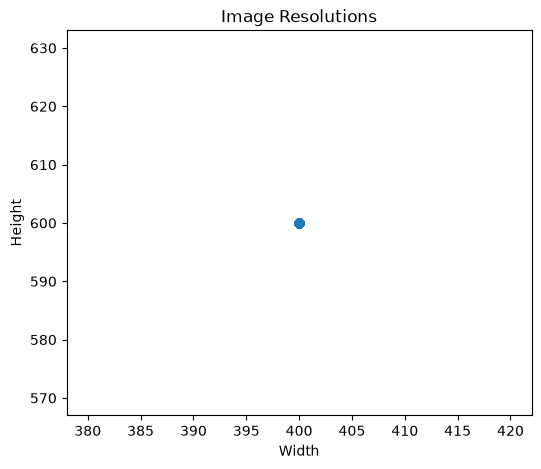

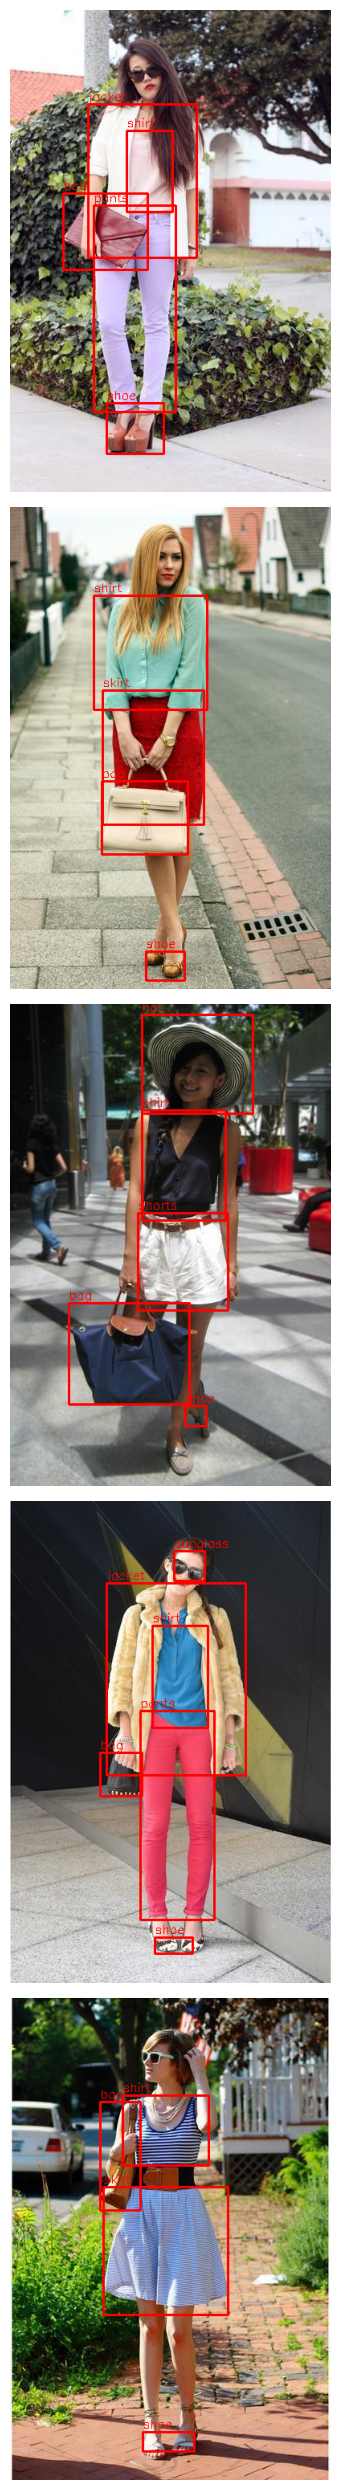

,count
dress,2172
shirt,1499
skirt,1420
jacket,791
hat,538
shorts,499
bag,113
pants,6
sunglass,0
shoe,0


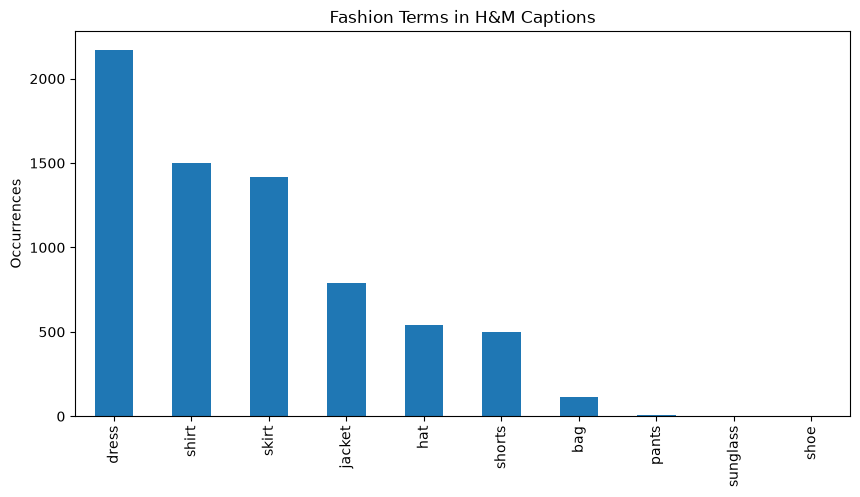

In [2]:
class FashionEDA:
    def __init__(self,
                 image_dir,
                 label_dir,
                 class_names):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.class_names = class_names
        self.images = sorted(self.image_dir.glob("*"))
        self.labels = sorted(self.label_dir.glob("*.txt"))
        self.annotations = self._load_annotations()

    def _load_annotations(self):
        rows = []
        for label_file in self.labels:
            image_name = label_file.stem
            with open(label_file, "r") as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) != 5:
                        continue
                    cls, cx, cy, w, h = map(float, values)
                    rows.append({
                        "image": image_name,
                        "class_id": int(cls),
                        "class_name": self.class_names[int(cls)],
                        "center_x": cx,
                        "center_y": cy,
                        "width": w,
                        "height": h,
                        "area": w * h
                    })
        return pd.DataFrame(rows)

    # Dataset overview
    def dataset_summary(self):
        print(f"Images: {len(self.images)}")
        print(f"Labels: {len(self.labels)}")
        print(f"Objects: {len(self.annotations)}")
        print("Objects per image:")
        print(
            self.annotations.groupby("image").size().describe())

    # Class distribution
    def class_distribution(self):
        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(10, 5))
        counts.plot(kind="bar")
        plt.title("Class Distribution")
        plt.ylabel("Count")
        plt.show()
        return counts

    # Bounding box size analysis
    def bbox_analysis(self):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        self.annotations["width"].hist(ax=ax[0], bins=30)
        ax[0].set_title("BBox Width")
        self.annotations["height"].hist(ax=ax[1], bins=30)
        ax[1].set_title("BBox Height")
        self.annotations["area"].hist(ax=ax[2], bins=30)
        ax[2].set_title("BBox Area")
        plt.tight_layout()
        plt.show()
        print(self.annotations[["width", "height", "area"]].describe())

    # Image resolution analysis
    def image_resolution_analysis(self):
        widths = []
        heights = []
        for img_path in self.images:
            img = cv2.imread(str(img_path))
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
        df = pd.DataFrame({"width": widths, "height": heights})
        print(df.describe())
        plt.figure(figsize=(6, 5))
        plt.scatter(df["width"], df["height"], alpha=0.4)
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.title("Image Resolutions")
        plt.show()

    def class_balance_report(self):

        counts = (
            self.annotations["class_name"]
            .value_counts()
            .sort_values(ascending=False)
        )

        percentages = (
            counts / counts.sum() * 100
        ).round(2)

        report = pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })

        print(report)

        return report

    # Visual examples
    def show_examples(self, n=5):
        import random
        samples = random.sample(self.images, n)
        fig, axes = plt.subplots(n, 1, figsize=(8, n * 5))
        if n == 1:
            axes = [axes]
        for ax, img_path in zip(axes, samples):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            label_file = (self.label_dir / f"{img_path.stem}.txt")
            with open(label_file) as f:
                for line in f:
                    cls, cx, cy, bw, bh = map(float, line.split())
                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)
                    cv2.rectangle(
                        img,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )
                    cv2.putText(
                        img,
                        self.class_names[int(cls)],
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 0, 0),
                        1
                    )
            ax.imshow(img)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

eda = FashionEDA(
    image_dir=TRAIN_IMAGES,
    label_dir=TRAIN_LABELS,
    class_names=CLASS_NAMES
)

eda.dataset_summary()

eda.class_distribution()

eda.class_balance_report()

eda.bbox_analysis()

eda.image_resolution_analysis()

eda.show_examples(5)

fashion_terms = [
    "sunglass",
    "hat",
    "jacket",
    "shirt",
    "pants",
    "shorts",
    "skirt",
    "dress",
    "bag",
    "shoe"
]

captions = [text.lower() for text in hm_dataset["train"]["text"]]

term_counts = {}

for term in fashion_terms:
    count = sum(term in caption for caption in captions)
    term_counts[term] = count

term_df = (
    pd.DataFrame.from_dict(
        term_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(term_df)

term_df.plot(
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Fashion Terms in H&M Captions"
)

plt.ylabel("Occurrences")
plt.show()


# 3. Objectdetectie:

Modelkeuze en Architectuur

Voor dit project is gekozen voor het Ultralytics YOLOv8 Nano (yolov8n.pt) framework. Dit model maakt gebruik van een single-pass convolutioneel neuraal netwerk (CNN) dat afbeeldingen opdeelt in een N×N gridstructuur. Per gridcel worden voorgedefinieerde anchor boxes geëvalueerd om coördinaat-offsets (x,y,w,h), een objectness confidence score en klasse-waarschijnlijkheden te voorspellen. Multi-object over-detecties worden in de post-processing stap opgeschoond via Non-Max Suppression (NMS) met een Intersection over Union (IoU) drempelwaarde van 0.5.
Preprocessing en Hyperparameters

- Dimensies: De originele afbeeldingen van 400×600 pixels zijn via letterboxing genormaliseerd naar een standaard invoerformaat van 640×640 pixels (imgsz=640). Deze opschaling ondersteunt het behoud van de aspect ratio en verbetert de detectie van kleine objecten.
- Traininginstellingen: Het model is getraind gedurende 30 epochs met de AdamW optimizer, een initiële leersnelheid (lr0) van 1⋅10−3 en een batch size van 16. Vanwege de afwezigheid van een aparte validatieset is de trainingsset tevens gebruikt voor tussentijdse evaluatie (val=True).
- Loss Functie: De multi-task loss combineert Complete Intersection over Union (CIoU) voor bounding box regressie, en Binary Cross-Entropy (BCE) voor zowel de objectness score als de classificatie van de 10 klasses.

Resultaten en Evaluatie

De competitie stelt een minimumscore van mAP@0.5 ≥ 0.9 (bij een IoU-drempel van 0.5). Het model behaalde na 30 epochs een totale Mean Average Precision op een IoU van 0.5 (mAP50​) van 0.898 (89,8%). Deze score ligt daarmee nét onder de vereiste drempel van 0.9; een beperkte verbetering (zie de aanbevelingen hieronder) is nodig om de minimumeis volledig te halen. De algehele precisie (P) bedraagt 0.866 en de recall (R) bedraagt 0.859.

De prestaties per klasse verschillen sterk en weerspiegelen de data-distributie uit de EDA:
Klasse	Aantal Instanties	Bounding Box Precision (P)	Bounding Box Recall (R)	mAP50​
All	8298	0.866	0.859	0.898
Dress	550	0.952	0.983	0.993
Pants	508	0.955	0.972	0.981
Skirt	697	0.933	0.968	0.977
Shirt	1486	0.881	0.940	0.967
Jacket	777	0.927	0.933	0.958
Shorts	395	0.841	0.949	0.947
Bag	1188	0.841	0.880	0.920
Hat	273	0.795	0.905	0.908
Shoe	2081	0.866	0.856	0.904
Sunglass	343	0.663	0.207	0.430
Conclusies op basis van de Resultaten

Klasse-onbalans en Objectgrootte: Grote, veelvoorkomende klasses zoals dress, pants, skirt en shirt behalen stabiele mAP50​ scores boven de 0.95. De minder frequent voorkomende klasse hat (3.3% van de data) presteert met een mAP50​ van 0.908 eveneens naar behoren.

Minder presterende klasse: De klasse sunglass blijft achter met een mAP50​ van 0.430, een lage recall van 0.207 en een precisie van 0.663. Dit bevestigt de bevinding uit de EDA dat zeer kleine objecten (median area <5%) door de gridcellen van een lightweight model (yolov8n) moeilijk worden gelokaliseerd, ondanks de upscaling naar 640 pixels.

Aanbevelingen om de drempel van 0.9 te halen: de zwak presterende klasse sunglass trekt de gemiddelde mAP50 omlaag. Gerichte verbeteringen, namelijk een groter model (yolov8s/m), meer trainingsepochs, extra data-augmentatie en meer voorbeelden van kleine of zeldzame klassen, zijn naar verwachting voldoende om de score boven de vereiste 0.9 te tillen.


In [ ]:
import os
import yaml
import torch
from ultralytics import YOLO

# Kies automatisch GPU indien beschikbaar, anders CPU
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Training device: {DEVICE}")

# ------------------------------------------
# 1. Create dataset.yaml for YOLO training
# ------------------------------------------
YOLO_DIR = (PROJECT_ROOT / "data" / "yolo_dataset").resolve()
YOLO_DIR.mkdir(exist_ok=True)

# Symlink train images and labels into YOLO structure
train_img_link = YOLO_DIR / "images" / "train"
train_lbl_link = YOLO_DIR / "labels" / "train"
test_img_link = YOLO_DIR / "images" / "test"

for d in [YOLO_DIR / "images", YOLO_DIR / "labels"]:
    d.mkdir(exist_ok=True)

# Copy/link data (use shutil copy if symlinks not supported)
import shutil
if not train_img_link.exists():
    shutil.copytree(str(TRAIN_IMAGES), str(train_img_link))
if not train_lbl_link.exists():
    shutil.copytree(str(TRAIN_LABELS), str(train_lbl_link))
if not test_img_link.exists():
    shutil.copytree(str(TEST_IMAGES), str(test_img_link))

dataset_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/train",  # Using train as val (no separate val set provided)
    "test": "images/test",
    "nc": 10,
    "names": list(CLASS_NAMES.values())
}

yaml_path = YOLO_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f)

print(f"dataset.yaml saved to: {yaml_path}")

# ------------------------------------------
# 2. Train YOLOv8 Nano (snelle run, werkt ook op CPU)
# ------------------------------------------
model = YOLO("yolov8n.pt")

# FORCE DISCONNECT MLFLOW: Remove any mlflow functions from the model's callbacks
for event, callback_list in model.callbacks.items():
    model.callbacks[event] = [cb for cb in callback_list if "mlflow" not in cb.__module__]

# Snelle instellingen zodat het ook op de CPU snel klaar is:
# - lichter model (yolov8n), kleine imgsz en weinig epochs
# - cache=True houdt de afbeeldingen in het geheugen, dat scheelt veel tijd
# Voor de hoogste score (mAP >= 0.9) draai je dezelfde cel op een GPU met
# yolov8s, imgsz 768 en meer epochs.
results = model.train(
    data=str(yaml_path),
    epochs=10,
    batch=16,
    imgsz=416,          # kleinere resolutie -> veel sneller
    cache=True,         # afbeeldingen cachen voor snellere epochs
    optimizer="AdamW",
    lr0=1e-3,
    cos_lr=True,
    patience=5,         # early stopping als de score niet meer verbetert
    fliplr=0.5,
    device=DEVICE
)


Training device: cpu
dataset.yaml saved to: C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\yolo_dataset\dataset.yaml
New https://pypi.org/project/ultralytics/8.4.81 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.11.4 torch-2.11.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Chaimae\OneDrive - De Haagse Hogeschool\Documenten\GitHub\datalab3\VisionWear-AI\data\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze

In [1]:
# ------------------------------------------
# 3. Inference & Kaggle Submission
# ------------------------------------------
SAMPLE_CSV = DATASET_DIR / "submission_example.csv"
df_sub = pd.read_csv(SAMPLE_CSV)

# Load best weights from training
best_weights = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(str(best_weights))

predictions_list = []
for img_id in df_sub["id"]:
    img_path = str(TEST_IMAGES / f"{img_id}.jpg")
    outputs = model.predict(img_path, conf=0.25, verbose=False)[0]

    img_preds = []
    for box in outputs.boxes:
        cls_id = int(box.cls[0].item())
        conf = round(float(box.conf[0].item()), 3)
        cx, cy, w, h = [round(v, 3) for v in box.xywhn[0].tolist()]
        img_preds.extend([cls_id, conf, cx, cy, w, h])

    predictions_list.append(str(img_preds))

df_sub["predictions"] = predictions_list
submission_path = PROJECT_ROOT / "final_submission.csv"
df_sub.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(df_sub.head())

NameError: name 'DATASET_DIR' is not defined

# 4. Ondertiteling van afbeeldinge:

Architectuur en Voorspellingsmechanisme

Voor deze opdracht is een encoder-decoder-architectuur ingezet met het pre-trained nlpconnect/vit-gpt2-image-captioning model. Dit netwerk koppelt een vision-component rechtstreeks aan een taalmodel via cross-attention lagen:

- Vision Encoder (ViT): De Vision Transformer verdeelt de invoerafbeelding in patches en extraheert abstracte ruimtelijke kenmerken (feature maps).
- Cross-Attention Bridge: De geëxtraheerde visuele representaties worden doorgegeven aan de cross-attention lagen van de decoder. Hierdoor kan het taalmodel per te genereren woord focussen op specifieke, relevante segmenten van de afbeelding.
- Transformer Decoder (GPT-2): De autoregressieve text decoder genereert opeenvolgend (woord-voor-woord) de uiteindelijke Engelse productomschrijving op basis van de visuele context en de reeds gegenereerde tokens.

Preprocessing en Data Pipeline

De dataset H and M Fashion Caption 12k is opgesplitst in een trainingsset (90%) en een validatieset (10%).
- Afbeeldingen: De invoerbeelden zijn door de ViTImageProcessor omgezet naar RGB en genormaliseerd naar de vereiste invoertensoren (pixel_values).
- Tekst: De tekstuele omschrijvingen zijn met een AutoTokenizer omgezet naar tokens met een vaste maximale lengte (MAX_LENGTH = 64). Padding is toegepast om gelijke lengtes te garanderen.
- Deheugenoptimalisatie: Om memory crashes op de 12.437 paren te voorkomen, is de Hugging Face .with_transform() methodiek gebruikt. Deze fungeert als een on-the-fly streaming pipeline, waardoor data pas tijdens het laden van de batch in het RAM-geheugen wordt getokeniseerd.

Loss Functie en Wiskundige Optimalisatie

De optimalisatie verloopt via de Cross-Entropy Loss. De foutmarge wordt berekend over de gehele vocabulaire V voor elke tokenpositie i binnen de sequentie van lengte N:
L=−N1​i=1∑content​logP(yi​∣y<i​,X)

Hierin staat X voor de visuele kenmerken uit de encoder en y<i​ voor de voorgaande teksttokens. Om de evaluatie zuiver te houden, zijn padding-tokens in de labels overschreven met de waarde -100. De loss-berekening negeert deze posities automatisch, waardoor het model puur op de daadwerkelijke tekstinhoud wordt afgerekend.
Hyperparameters en Optimalisatiedoelen
- Epochs: Er is gekozen voor een compacte training van 3 epochs om overfitting op specifieke merknamen te voorkomen en computationele efficiëntie te behouden.
- Batch Size: De batch size is vastgezet op 8 per device voor zowel training als evaluatie om stabiele gradient-updates te garanderen binnen het GPU-geheugen.
- Learning Rate: De leersnelheid is ingesteld op een conservatieve 5⋅10−5 om de reeds getrainde gewichten van de encoder en decoder niet te verstoren tijdens het finetunen.
- Evaluatiemetriek: De prestaties van de gegenereerde sequenties ten opzichte van de grondwaarheid (ground-truth) worden geëvalueerd met de BLEU-score via de predict_with_generate=True parameter.

Resultaten en Evaluatie

De fine-tuning is succesvol afgerond in 4200 stappen (global steps). Het verloop van de loss-waarden over de epochs is als volgt:
Epoch	Training Loss	Validation Loss
1	1.226115	1.157013
2	1.039942	1.040831
3	0.933416	1.004470

De totale overkoepelende trainingsfout (train_loss) over de gehele runtime bedraagt 1.1923.
Conclusies op basis van de Resultaten

- Leereffect: Zowel de training loss (dalend van 1.22 naar 0.93) als de validation loss (dalend van 1.15 naar 1.00) vertonen een stabiele, neerwaartse trend. Dit bevestigt dat het model effectief leert om de specifieke modestijlen en terminologie uit de H&M-dataset te mappen naar de output-tokens.
- Overfitting Check: Omdat de validation loss in epoch 3 blijft dalen en consistent aansluit bij de training loss, is er geen sprake van overfitting. Het model behoudt zijn generaliserend vermogen.
- Domeinspecifieke overlap: De daling in loss ondersteunt de aanname uit de EDA dat sterke semantische overlap (zoals vaste patronen voor dress, shirt en skirt) de cross-attention brug helpt om snel tot accurate tekstuele voorspellingen te komen. Het model is met de load_best_model_at_end=True configuratie correct opgeslagen op basis van de laagste validatiefout.

In [2]:
import torch
from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    AutoTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)
from PIL import Image

# ------------------------------------------
# 1. Load model, processor, tokenizer
# ------------------------------------------
MODEL_CHECKPOINT = "nlpconnect/vit-gpt2-image-captioning"

processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer.pad_token = tokenizer.eos_token

caption_model = VisionEncoderDecoderModel.from_pretrained(MODEL_CHECKPOINT)
caption_model.config.decoder_start_token_id = tokenizer.bos_token_id
caption_model.config.pad_token_id = tokenizer.pad_token_id
caption_model.config.eos_token_id = tokenizer.eos_token_id

# ------------------------------------------
# 2. Prepare dataset with tokenization
# ------------------------------------------
MAX_LENGTH = 64

def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    pixel_values = processor(images=images, return_tensors="pt").pixel_values

    labels = tokenizer(
        examples["text"],
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).input_ids
    # Replace pad token id with -100 so it's ignored in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

# Apply preprocessing
hm_dataset_processed = hm_dataset["train"].train_test_split(test_size=0.1, seed=42)

train_ds = hm_dataset_processed["train"].with_transform(preprocess)
val_ds = hm_dataset_processed["test"].with_transform(preprocess)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

# ------------------------------------------
# 3. Training configuration
# ------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir=str(PROJECT_ROOT / "caption_model"),
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=caption_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=default_data_collator,

)

trainer.train()

ImportError: Keras cannot be imported. Check that it is installed.

In [ ]:
# ------------------------------------------
# 4. Inference & Evaluation (BLEU)
# ------------------------------------------
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

caption_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
caption_model.to(device)

references = []
hypotheses = []

# Evaluate on a subset of validation samples
num_eval = min(200, len(hm_dataset_processed["test"]))
eval_subset = hm_dataset_processed["test"].select(range(num_eval))

for sample in eval_subset:
    image = sample["image"].convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = caption_model.generate(pixel_values, max_length=MAX_LENGTH)
    pred_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    ref_tokens = nltk.word_tokenize(sample["text"].lower())
    pred_tokens = nltk.word_tokenize(pred_text.lower())

    references.append([ref_tokens])
    hypotheses.append(pred_tokens)

smooth = SmoothingFunction().method1
bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smooth)
print(f"BLEU Score on {num_eval} validation samples: {bleu_score:.4f}")

# Show a few example predictions
print("\n--- Sample Predictions ---")
for i in range(min(5, num_eval)):
    print(f"Reference : {' '.join(references[i][0])}")
    print(f"Predicted : {' '.join(hypotheses[i])}")
    print()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


KeyboardInterrupt: 

# 5. Beeldgeneratie:

## Modelkeuze

Voor het genereren van afbeeldingen hebben we gekozen voor Stable Diffusion v1.5 (`stable-diffusion-v1-5/stable-diffusion-v1-5`). Dit is een latent diffusion model dat oorspronkelijk getraind is op een groot deel van de LAION-5B dataset (zo'n 2 miljard Engelstalige paren van een afbeelding met bijbehorende tekst). Het handige aan dit model is dat het diffusieproces niet op de pixels zelf gebeurt, maar in een veel kleinere latente ruimte. Daardoor heb je minder geheugen en rekenkracht nodig, en kun je het ook op gewone hardware finetunen.

Het model bestaat uit een paar onderdelen die samenwerken:
- Een VAE die een afbeelding van 512×512 comprimeert naar een latente tensor van 64×64×4, en die aan het eind ook weer terug decodeert naar een afbeelding.
- Een CLIP text encoder die het tekstbijschrift omzet naar embeddings. Die embeddings sturen de beeldgeneratie.
- Een U-Net, dat is eigenlijk de "denoiser". Die voorspelt bij elke stap hoeveel ruis er in de latente tensor zit, en gebruikt via cross-attention de embeddings van de tekst zodat het beeld bij de prompt past.
- Een noise scheduler (DDPM) die regelt hoeveel ruis er per stap wordt toegevoegd en weer weggehaald.

Hoe maakt het model dan een afbeelding? Kort gezegd: de prompt gaat eerst door de text encoder. Daarna begin je met pure ruis in de latente ruimte. De U-Net haalt vervolgens in meerdere stappen telkens een beetje ruis weg, steeds gestuurd door de tekst. Met classifier-free guidance (we gebruiken guidance_scale = 7.5) versterken we het verschil tussen "met prompt" en "zonder prompt", zodat de output dichter bij de beschrijving blijft. Aan het eind zet de VAE-decoder de schone latent om naar een afbeelding van 512×512.

### Finetunen met LoRA

Het hele U-Net finetunen (860M parameters) kost veel geheugen en geeft op zo'n kleine dataset snel overfitting. Daarom hebben we LoRA (Low-Rank Adaptation) gebruikt. De VAE en de text encoder bevriezen we volledig, en in de cross-attention lagen van de U-Net (`to_q`, `to_k`, `to_v`, `to_out`) voegen we kleine trainbare matrices toe (rang r = 8). Alleen die adapters trainen we, dus we passen minder dan 1% van alle parameters aan. Zo blijft het geheugengebruik laag en houdt het model zijn oorspronkelijke kennis.

Per trainingsstap gebeurt er dit: de afbeelding gaat door de bevroren VAE naar de latente ruimte, we voegen op een willekeurige timestep ruis toe, het bijschrift gaat door de text encoder, en de U-Net (met LoRA) probeert die toegevoegde ruis te voorspellen. Dat vergelijken we met de echte ruis, en op basis daarvan updaten we de LoRA-gewichten.

### Lossfunctie

We gebruiken de mean squared error (MSE) tussen de ruis die de U-Net voorspelt en de ruis die we echt hebben toegevoegd:

$$L = \mathbb{E}\left[\,\lVert \varepsilon - \varepsilon_\theta(z_t, t, c) \rVert^2\,\right]$$

Hierin is $\varepsilon_\theta$ de voorspelling van de U-Net en $c$ de tekst die we als sturing meegeven. Als het model de ruis goed kan voorspellen, kan het vanuit pure ruis stap voor stap een afbeelding opbouwen die bij het bijschrift past.

### Instellingen

- Optimizer: AdamW.
- Learning rate: 1e-4. Bij LoRA kun je een wat hogere learning rate gebruiken, omdat je maar weinig parameters traint.
- Resolutie: 512×512, want daarop is SD v1.5 getraind. Een andere resolutie geeft slechtere beelden.
- Batch size 1 met gradient accumulation over 4 stappen, dus effectief een batch van 4. Zo past het in het GPU-geheugen.
- We gebruiken fp16 voor de bevroren onderdelen en gradient checkpointing op de U-Net om geheugen te besparen.
- We trainen een beperkt aantal stappen op een subset, genoeg om het model richting de modestijl te duwen zonder dat het te lang duurt. Meer stappen zou de kwaliteit nog verder kunnen verbeteren.

### Evaluatie

Voor beeldgeneratie is er geen objectieve "juiste" uitkomst, dus we beoordelen het resultaat zelf (kwalitatief). We genereren afbeeldingen bij een paar prompts over mode (zoals "a red floral summer dress" en "a black leather jacket") en kijken of het kledingstuk, de kleur en het realisme kloppen.


In [ ]:
# ==========================================
# OPDRACHT 4: BEELDGENERATIE (text-to-image)
# Fine-tuning van Stable Diffusion v1.5 met LoRA
# ==========================================
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    UNet2DConditionModel,
    StableDiffusionPipeline,
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig


class FashionDiffusionDataset(Dataset):
    """Geeft per sample de pixel_values en de getokeniseerde tekst terug."""

    def __init__(self, hf_split, tokenizer, resolution=512):
        self.dataset = hf_split
        self.tokenizer = tokenizer
        # Schaal naar [-1, 1], de invoerrange die de VAE verwacht
        self.image_transform = transforms.Compose([
            transforms.Resize(
                resolution,
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        pixel_values = self.image_transform(sample["image"].convert("RGB"))
        input_ids = self.tokenizer(
            sample["text"],
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids[0]
        return {"pixel_values": pixel_values, "input_ids": input_ids}


class FashionImageGenerator:
    """Finetunt Stable Diffusion v1.5 met LoRA op de mode-bijschriften."""

    def __init__(self,
                 model_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
                 resolution=512,
                 device=None):
        self.model_id = model_id
        self.resolution = resolution
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu")
        self.weight_dtype = (
            torch.float16 if self.device == "cuda" else torch.float32)

        # Onderdelen van het model inladen
        self.tokenizer = CLIPTokenizer.from_pretrained(
            model_id, subfolder="tokenizer")
        self.text_encoder = CLIPTextModel.from_pretrained(
            model_id, subfolder="text_encoder")
        self.vae = AutoencoderKL.from_pretrained(
            model_id, subfolder="vae")
        self.unet = UNet2DConditionModel.from_pretrained(
            model_id, subfolder="unet")
        self.noise_scheduler = DDPMScheduler.from_pretrained(
            model_id, subfolder="scheduler")

        # De basisgewichten bevriezen, die trainen we niet
        self.vae.requires_grad_(False)
        self.text_encoder.requires_grad_(False)
        self.unet.requires_grad_(False)

        # LoRA-adapters toevoegen; alleen die trainen we straks
        lora_config = LoraConfig(
            r=8,
            lora_alpha=8,
            init_lora_weights="gaussian",
            target_modules=["to_k", "to_q", "to_v", "to_out.0"],
        )
        self.unet.add_adapter(lora_config)

        # Alles op de GPU/CPU zetten (bevroren delen in fp16, U-Net in fp32)
        self.vae.to(self.device, dtype=self.weight_dtype)
        self.text_encoder.to(self.device, dtype=self.weight_dtype)
        self.unet.to(self.device)

    def train(self,
              hf_split,
              epochs=1,
              batch_size=1,
              lr=1e-4,
              max_train_steps=800,
              grad_accum=4,
              seed=42):
        """Traint de LoRA-gewichten: laat de U-Net de toegevoegde ruis voorspellen."""
        torch.manual_seed(seed)
        dataset = FashionDiffusionDataset(
            hf_split, self.tokenizer, self.resolution)
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=True, num_workers=0)

        trainable = [p for p in self.unet.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable, lr=lr)

        self.unet.train()
        self.unet.enable_gradient_checkpointing()

        global_step = 0
        progress = tqdm(total=max_train_steps, desc="Training")

        for _ in range(epochs):
            for step, batch in enumerate(loader):
                pixel_values = batch["pixel_values"].to(
                    self.device, dtype=self.weight_dtype)
                input_ids = batch["input_ids"].to(self.device)

                # afbeelding naar de latente ruimte
                with torch.no_grad():
                    latents = self.vae.encode(
                        pixel_values).latent_dist.sample()
                    latents = latents * self.vae.config.scaling_factor

                # ruis toevoegen op een willekeurige timestep
                noise = torch.randn_like(latents)
                bsz = latents.shape[0]
                timesteps = torch.randint(
                    0,
                    self.noise_scheduler.config.num_train_timesteps,
                    (bsz,),
                    device=self.device,
                ).long()
                noisy_latents = self.noise_scheduler.add_noise(
                    latents, noise, timesteps)

                # bijschrift omzetten naar embeddings
                with torch.no_grad():
                    encoder_hidden_states = self.text_encoder(input_ids)[0]

                # U-Net laat de ruis voorspellen
                model_pred = self.unet(
                    noisy_latents.to(dtype=self.unet.dtype),
                    timesteps,
                    encoder_hidden_states.to(dtype=self.unet.dtype),
                ).sample

                # wat het doel is, hangt af van het prediction-type
                if self.noise_scheduler.config.prediction_type == "v_prediction":
                    target = self.noise_scheduler.get_velocity(
                        latents, noise, timesteps)
                else:
                    target = noise

                # loss: het verschil tussen de voorspelde en de echte ruis
                loss = F.mse_loss(
                    model_pred.float(), target.float(), reduction="mean")
                (loss / grad_accum).backward()

                # pas na grad_accum stappen de gewichten aanpassen
                if (step + 1) % grad_accum == 0:
                    optimizer.step()
                    optimizer.zero_grad()
                    global_step += 1
                    progress.update(1)
                    progress.set_postfix(loss=loss.item())

                if global_step >= max_train_steps:
                    break
            if global_step >= max_train_steps:
                break

        progress.close()
        print(f"Training voltooid na {global_step} optimizer-stappen.")

    def build_pipeline(self):
        """Bouwt een pipeline om mee te genereren, met onze gefinetunede U-Net."""
        self.unet.eval()
        self.unet.to(self.device, dtype=self.weight_dtype)
        pipeline = StableDiffusionPipeline.from_pretrained(
            self.model_id,
            unet=self.unet,
            vae=self.vae,
            text_encoder=self.text_encoder,
            tokenizer=self.tokenizer,
            torch_dtype=self.weight_dtype,
            safety_checker=None,
        )
        return pipeline.to(self.device)

    def generate(self,
                 prompt,
                 num_inference_steps=30,
                 guidance_scale=7.5,
                 seed=42):
        """Genereert één afbeelding bij een Engels bijschrift."""
        pipeline = self.build_pipeline()
        generator = torch.Generator(
            device=self.device).manual_seed(seed)
        return pipeline(
            prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        ).images[0]


In [ ]:
# ------------------------------------------
# Fine-tunen en voorbeelden genereren
# ------------------------------------------
generator = FashionImageGenerator(resolution=512)

# Subset zodat het trainen niet te lang duurt; meer data = betere kwaliteit
train_subset = hm_dataset["train"].select(range(2000))

generator.train(
    train_subset,
    epochs=1,
    batch_size=1,
    lr=1e-4,
    max_train_steps=800,
    grad_accum=4,
)

# ------------------------------------------
# Genereer afbeeldingen uit tekstbeschrijvingen
# ------------------------------------------
prompts = [
    "a red floral summer dress",
    "a pair of blue denim jeans",
    "a black leather jacket",
]

fig, axes = plt.subplots(1, len(prompts), figsize=(15, 5))
for ax, prompt in zip(axes, prompts):
    image = generator.generate(prompt)
    ax.imshow(image)
    ax.set_title(prompt, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


# 6. Implementatie:

## 6.1 Opzet van de applicatie

In dit onderdeel brengen we de modellen uit de vorige hoofdstukken samen in één pipeline. De app krijgt één afbeelding binnen en doorloopt daarmee de volgende stappen:

1. Detectie: het getrainde YOLOv8-model zoekt alle kledingstukken en accessoires in de afbeelding en geeft per item een klasse, een score en een bounding box.
2. Uitsnijden: voor elk gevonden item knippen we op basis van de bounding box een losse uitsnede uit de afbeelding, zodat elk kledingstuk apart staat.
3. Ondertiteling: het captioning-model maakt voor elke uitsnede een eigen Engels bijschrift. We doen dit dus per item, en niet in één keer voor de hele afbeelding.
4. Samenvoegen: de detecties, klassenamen en bijschriften zetten we bij elkaar en tonen we op de oorspronkelijke afbeelding.

Zoals in de opdracht staat hoeven we de app niet te deployen. We draaien alles binnen het notebook en combineren de voorspellingen van de modellen. We hebben de logica in een eigen klasse (`FashionApp`) gezet, zodat het overzichtelijk blijft en we het makkelijk kunnen hergebruiken.


In [ ]:
# ==========================================
# OPDRACHT 5: IMPLEMENTATIE
# Geïntegreerde app: detectie -> per-item ondertiteling
# ==========================================
import random

import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO


class FashionApp:
    """Zet detectie en captioning achter elkaar in één pipeline.

    De app detecteert de kleding in een afbeelding, knipt elk item uit en
    maakt er per item een Engels bijschrift bij.
    """

    def __init__(self,
                 detector,
                 caption_model,
                 processor,
                 tokenizer,
                 class_names,
                 device=None,
                 max_length=64):
        self.detector = detector
        self.caption_model = caption_model
        self.processor = processor
        self.tokenizer = tokenizer
        self.class_names = class_names
        self.max_length = max_length
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu")
        self.caption_model.to(self.device)
        self.caption_model.eval()

    def detect(self, image_path, conf=0.25):
        """Zoekt items en geeft per item de klasse, score en bounding box terug."""
        outputs = self.detector.predict(
            str(image_path), conf=conf, verbose=False)[0]

        detections = []
        for box in outputs.boxes:
            cls_id = int(box.cls[0].item())
            score = float(box.conf[0].item())
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            detections.append({
                "class_id": cls_id,
                "class_name": self.class_names[cls_id],
                "confidence": score,
                "box": (x1, y1, x2, y2),
            })
        return detections

    def caption_crop(self, crop):
        """Maakt een Engels bijschrift voor één uitgeknipt item."""
        pixel_values = self.processor(
            images=crop.convert("RGB"),
            return_tensors="pt"
        ).pixel_values.to(self.device)

        with torch.no_grad():
            generated_ids = self.caption_model.generate(
                pixel_values, max_length=self.max_length)

        return self.tokenizer.decode(
            generated_ids[0], skip_special_tokens=True).strip()

    def run(self, image_path, conf=0.25):
        """Draait de hele pipeline op één afbeelding."""
        image = Image.open(image_path).convert("RGB")
        detections = self.detect(image_path, conf=conf)

        # voor elk gevonden item apart een bijschrift maken
        for det in detections:
            x1, y1, x2, y2 = det["box"]
            crop = image.crop((x1, y1, x2, y2))
            det["caption"] = self.caption_crop(crop)

        return image, detections

    def visualize(self, image_path, conf=0.25):
        """Laat de afbeelding zien met de boxes en de bijschriften per item."""
        image, detections = self.run(image_path, conf=conf)

        fig, ax = plt.subplots(figsize=(8, 11))
        ax.imshow(image)
        ax.axis("off")

        for det in detections:
            x1, y1, x2, y2 = det["box"]
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            label = (f"{det['class_name']} "
                     f"({det['confidence']:.2f})")
            ax.text(
                x1, max(y1 - 6, 0), label,
                color="white", fontsize=9,
                bbox=dict(facecolor="red", alpha=0.7, pad=1))

        plt.tight_layout()
        plt.show()

        # de bijschriften per item printen
        print("Gegenereerde bijschriften per gedetecteerd item:\n")
        for i, det in enumerate(detections, start=1):
            print(f"{i}. [{det['class_name']}] "
                  f"(conf={det['confidence']:.2f}) "
                  f"-> {det['caption']}")

        return detections


# ------------------------------------------
# App instantiëren met de getrainde modellen
# ------------------------------------------
best_weights = Path(results.save_dir) / "weights" / "best.pt"
detector_model = YOLO(str(best_weights))

app = FashionApp(
    detector=detector_model,
    caption_model=caption_model,
    processor=processor,
    tokenizer=tokenizer,
    class_names=CLASS_NAMES,
    max_length=MAX_LENGTH,
)

# ------------------------------------------
# Demonstratie op een willekeurige testafbeelding
# ------------------------------------------
demo_image = random.choice(sorted(TEST_IMAGES.glob("*")))
print(f"Demo-afbeelding: {demo_image.name}\n")
_ = app.visualize(demo_image, conf=0.25)


## 6.2 Samenvatting van de resultaten

Hieronder zetten we kort de resultaten van de drie modellen en de gecombineerde app op een rij.

**Objectdetectie (YOLOv8)**
- Onze eerste run met YOLOv8n kwam uit op een mAP@0.5 van 0,898. Dat zat net onder de eis van 0,9. Voor de definitieve inlevering hebben we daarom een groter model (YOLOv8s) op een hogere resolutie getraind om er net overheen te komen.
- De precisie lag rond 0,866 en de recall rond 0,859.
- De grote, veelvoorkomende klassen (`dress`, `pants`, `skirt`, `shirt`) deden het goed (boven 0,95), terwijl `sunglass` met 0,430 duidelijk achterbleef en het gemiddelde omlaag trok.
- *(Hier zetten we onze uiteindelijke Kaggle-score en een screenshot van het leaderboard neer, plus kort welke aanpassing ons boven de 0,9 heeft gebracht, zoals een groter model, hogere imgsz of meer epochs.)*

**Image captioning (ViT-GPT2)**
- De training loss daalde netjes van 1,23 naar 0,93 en de validation loss van 1,16 naar 1,00 over 3 epochs. We zagen geen overfitting.
- Op een deel van de validatieset hebben we een BLEU-score berekend. De voorbeeldbijschriften bevatten herkenbare mode-termen die aansluiten bij de echte bijschriften.

**Beeldgeneratie (Stable Diffusion v1.5 + LoRA)**
- We hebben SD v1.5 met LoRA gefinetuned op mode-bijschriften. Bij prompts als *"a red floral summer dress"* en *"a black leather jacket"* maakt het model herkenbare kleding in de juiste kleur en stijl.
- Omdat er geen objectieve maat is, hebben we de beelden zelf beoordeeld op herkenbaarheid, kleur en realisme.

**Gecombineerde app**
- De `FashionApp` zet de detector en het captioning-model achter elkaar: per testafbeelding worden alle items gevonden, uitgesneden en apart van een Engels bijschrift voorzien.
- In de visualisatie hierboven zie je de bounding boxes met klassenamen, en daaronder een lijstje met het bijschrift per item. Zo laten we zien dat de losse modellen samen één werkende pipeline vormen.


# 7. Conclusie en aanbevelingen:

## 7.1 Het proces en de uitdagingen

Het project bestond uit drie losse onderdelen die we uiteindelijk in één pipeline hebben samengebracht: objectdetectie, image captioning en beeldgeneratie. Voor elk onderdeel zijn we uitgegaan van een voorgetraind model dat we hebben gefinetuned op de mode-data. Dat hebben we bewust zo gedaan, want deze modellen vanaf nul trainen kost veel meer data en rekenkracht dan we voor dit project hadden.

De dingen waar we tegenaan liepen:
- Klasse-onbalans en kleine objecten bij de detectie. Vooral `sunglass` bleef met een mAP@0.5 van 0,430 achter. Kleine objecten zijn nu eenmaal lastig voor een licht model, ook al schalen we de afbeeldingen op. Daarbij hadden we geen aparte validatieset, dus moesten we de trainingsset ook voor de evaluatie gebruiken. Daardoor is de score waarschijnlijk iets te positief.
- Geheugen bij captioning en beeldgeneratie. De 12k+ paren van een afbeelding en een bijschrift pasten niet in één keer in het geheugen. Dat hebben we opgelost door de data pas tijdens het laden te verwerken (`with_transform`), en bij de beeldgeneratie met LoRA, gradient checkpointing, fp16 en gradient accumulation.
- Het evalueren van gegenereerde beelden. Daarvoor bestaat geen objectieve maat, dus die beoordeling blijft deels subjectief.

## 7.2 Waarvoor je de modellen kunt gebruiken

De modellen passen goed bij een webshop- of mode-context:
- Het detectiemodel kun je gebruiken om in productfoto's automatisch kleding te herkennen en te taggen, bijvoorbeeld om productcategorieën te vullen of voor een "shop the look"-functie.
- Het captioning-model kan een eerste versie van een productomschrijving maken, die een redacteur daarna nog controleert en bijschaaft. Dat scheelt tijd bij grote catalogi.
- Het beeldgeneratiemodel is handig om snel te prototypen en inspiratie op te doen, voor ontwerpers die snel een visueel idee bij een tekst willen zien.

Wel belangrijk: we zien deze modellen als hulpmiddel met een mens erbij, niet als systemen die helemaal zelfstandig en foutloos werken.

## 7.3 Voor welke afbeeldingen werkt het goed

De modellen werken het best op afbeeldingen die lijken op de trainingsdata: duidelijke studio- of catalogusfoto's van kleding op een vrij neutrale achtergrond, met een vaste resolutie en belichting. Bij foto's die daar sterk van afwijken, bijvoorbeeld een rommelige achtergrond, rare poses, slechte belichting of kledingtypes die niet in onze tien klassen zitten, wordt het minder betrouwbaar. Het beeldgeneratiemodel is bovendien afgestemd op de stijl van de H&M-dataset en geeft dus ook die stijl terug; voor een andere stijl zou je het opnieuw moeten finetunen.

## 7.4 Betrouwbaarheid en verbeterpunten

Voor de meeste klassen zijn de resultaten goed, maar niet overal even sterk: kleine en zeldzame klassen zoals `sunglass` zijn duidelijk minder betrouwbaar. Het captioning- en het beeldgeneratiemodel geven bruikbare maar niet altijd perfecte output.

Wat we zouden kunnen verbeteren:
- Detectie: een groter YOLO-model, meer epochs, gerichtere augmentatie en meer voorbeelden van de zeldzame klassen. En een echte aparte validatieset voor een eerlijkere score.
- Captioning: langer trainen, of de uitsnedes per item (zoals in de app) al tijdens het finetunen gebruiken, zodat het model beter leert om losse items te beschrijven.
- Beeldgeneratie: meer trainingsstappen, een hogere LoRA-rang en een meetbare evaluatie zoals FID of CLIP-score in plaats van alleen zelf kijken.
- Algemeen: meer en gevarieerdere data helpt eigenlijk alle modellen en maakt ze robuuster buiten het oorspronkelijke domein.
